<center><h1>TP 4: Réseaux de Neurones Convolutifs- Optimsation et regularisation</h1></center>

## Avant de commencer le TP,
- vérifiez que vous êtes sur un environnement GPU et python 3 :
  
  Éxecution -> Modifier le type d'éxecution -> Type d'éxecution = python3, Accélerateur matériel = GPU

- Fichier -> Sauvegarder une copie dans mon drive

PARTIE N°1 :

### **1. Taille de sortie et nombre de poids**

La taille de sortie est : ((\frac{x - k + 2p}{s} + 1) \times (\frac{y - k + 2p}{s} + 1) \times 1).
Le nombre de poids est (k \times k \times z), beaucoup moins qu’une couche fully-connected qui connecterait tous les neurones.



### **2. Avantages et limite de la convolution**

La convolution réduit fortement le nombre de paramètres et exploite la structure spatiale des images. Sa limite est qu’elle capte surtout des informations locales.



### **3. Intérêt du pooling**

Le pooling permet de réduire la taille des données et donc le coût de calcul. Il rend aussi le modèle plus robuste aux petites variations de l’image.



### **4. Image plus grande en entrée**

Oui, on peut calculer les couches convolutionnelles car elles ne dépendent pas de la taille fixe. Les couches fully-connected posent problème car elles nécessitent une taille fixe.



### **5. Fully-connected comme convolution**

Une couche fully-connected peut être vue comme une convolution avec un kernel couvrant toute l’entrée. Elle relie tous les neurones entre eux.


### **6. Remplacement des fully-connected**

Oui, dans ce cas on peut traiter des images de taille variable. La sortie devient une carte d’activation, utile pour la détection ou la localisation.



### **7. Receptive field**

Dans les premières couches, le receptive field est petit et capte des détails locaux. Dans les couches profondes, il devient plus grand et capture des structures globales de l’image.


PARTIE N°2 :
### **8. Padding et stride pour les convolutions**

On choisit un **padding = 2** et un **stride = 1** pour conserver la même taille spatiale. Cela compense la taille du kernel 5×5.



### **9. Paramètres pour le max pooling**

On utilise un **kernel = 2×2**, **stride = 2** et **padding = 0**. Cela permet de diviser les dimensions par 2.



### **10. Taille de sortie et nombre de poids**

Les convolutions gardent la taille puis le pooling la réduit progressivement (32→16→8→4). La majorité des poids se trouve dans les couches fully-connected, qui sont très coûteuses.



### **11. Nombre total de poids**

Le nombre total de paramètres est très élevé (surtout à cause des couches FC) mais reste inférieur au nombre d’exemples. Cela permet au modèle d’apprendre sans trop sur-apprendre si bien réglé.



### **12. Comparaison avec BoW + SVM**

Le CNN apprend automatiquement les caractéristiques alors que BoW utilise des features fixes. Le CNN a souvent plus de paramètres mais offre de meilleures performances sur les images.


In [1]:
! wget https://raw.githubusercontent.com/deep-learning-polytech/deep-learning-polytech.github.io/master/code/TP5-6/utils.py

--2026-04-23 19:28:45--  https://raw.githubusercontent.com/deep-learning-polytech/deep-learning-polytech.github.io/master/code/TP5-6/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2627 (2.6K) [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]   2.57K  --.-KB/s    in 0s      

2026-04-23 19:28:45 (27.8 MB/s) - ‘utils.py’ saved [2627/2627]



In [2]:
import argparse
import os
import time

import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim
import torch.utils.data
import torchvision.transforms as transforms
import torchvision.datasets as datasets

from utils import *

PRINT_INTERVAL = 200
PATH="datasets"

In [3]:
class ConvNet(nn.Module):
    """
    Cette classe contient la structure du réseau de neurones
    """

    def __init__(self):
        super(ConvNet, self).__init__()
        # On défini d'abord les couches de convolution et de pooling comme un
        # groupe de couches `self.features`
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, (5, 5), stride=1, padding=2),
            nn.Tanh(),
            nn.MaxPool2d((2, 2), stride=2, padding=0),
            nn.Conv2d(6, 16, (5, 5), stride=1, padding=0),
            nn.Tanh(),
            nn.MaxPool2d((2, 2), stride=2, padding=0),
        )
        # On défini les couches fully connected comme un groupe de couches
        # `self.classifier`
        self.classifier = nn.Sequential(
            nn.Linear(400, 120),
            nn.Tanh(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, 10)
            # Rappel : Le softmax est inclus dans la loss, ne pas le mettre ici
        )

    # méthode appelée quand on applique le réseau à un batch d'input
    def forward(self, input):
        bsize = input.size(0) # taille du batch
        output = self.features(input) # on calcule la sortie des conv
        output = output.view(bsize, -1) # on applati les feature map 2D en un
                                        # vecteur 1D pour chaque input
        output = self.classifier(output) # on calcule la sortie des fc
        return output



def get_dataset(batch_size, cuda=False):
    """
    Cette fonction charge le dataset et effectue des transformations sur chaqu
    image (listées dans `transform=...`).
    """
    train_dataset = datasets.MNIST(PATH, train=True, download=True,
        transform=transforms.Compose([
            transforms.ToTensor()
        ]))
    val_dataset = datasets.MNIST(PATH, train=False, download=True,
        transform=transforms.Compose([
            transforms.ToTensor()
        ]))

    train_loader = torch.utils.data.DataLoader(train_dataset,
                        batch_size=batch_size, shuffle=True, pin_memory=cuda, num_workers=2)
    val_loader = torch.utils.data.DataLoader(val_dataset,
                        batch_size=batch_size, shuffle=False, pin_memory=cuda, num_workers=2)

    return train_loader, val_loader



def epoch(data, model, criterion, optimizer=None, cuda=False):
    """
    Fait une passe (appelée epoch en anglais) sur les données `data` avec le
    modèle `model`. Evalue `criterion` comme loss.
    Si `optimizer` est fourni, effectue une epoch d'apprentissage en utilisant
    l'optimiseur donné, sinon, effectue une epoch d'évaluation (pas de backward)
    du modèle.
    """

    # indique si le modele est en mode eval ou train (certaines couches se
    # comportent différemment en train et en eval)
    model.eval() if optimizer is None else model.train()

    # objets pour stocker les moyennes des metriques
    avg_loss = AverageMeter()
    avg_top1_acc = AverageMeter()
    avg_top5_acc = AverageMeter()
    avg_batch_time = AverageMeter()
    global loss_plot

    # on itere sur les batchs du dataset
    tic = time.time()
    for i, (input, target) in enumerate(data):

        if cuda: # si on fait du GPU, passage en CUDA
            input = input.cuda()
            target = target.cuda()

        # forward
        output = model(input)
        loss = criterion(output, target)

        # backward si on est en "train"
        if optimizer:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # calcul des metriques
        prec1, prec5 = accuracy(output, target, topk=(1, 5))
        batch_time = time.time() - tic
        tic = time.time()

        # mise a jour des moyennes
        avg_loss.update(loss.item())
        avg_top1_acc.update(prec1.item())
        avg_top5_acc.update(prec5.item())
        avg_batch_time.update(batch_time)
        if optimizer:
            loss_plot.update(avg_loss.val)
        # affichage des infos
        if i % PRINT_INTERVAL == 0:
            print('[{0:s} Batch {1:03d}/{2:03d}]\t'
                  'Time {batch_time.val:.3f}s ({batch_time.avg:.3f}s)\t'
                  'Loss {loss.val:.4f} ({loss.avg:.4f})\t'
                  'Prec@1 {top1.val:5.1f} ({top1.avg:5.1f})\t'
                  'Prec@5 {top5.val:5.1f} ({top5.avg:5.1f})'.format(
                   "EVAL" if optimizer is None else "TRAIN", i, len(data), batch_time=avg_batch_time, loss=avg_loss,
                   top1=avg_top1_acc, top5=avg_top5_acc))
            if optimizer:
                loss_plot.plot()

    # Affichage des infos sur l'epoch
    print('\n===============> Total time {batch_time:d}s\t'
          'Avg loss {loss.avg:.4f}\t'
          'Avg Prec@1 {top1.avg:5.2f} %\t'
          'Avg Prec@5 {top5.avg:5.2f} %\n'.format(
           batch_time=int(avg_batch_time.sum), loss=avg_loss,
           top1=avg_top1_acc, top5=avg_top5_acc))

    return avg_top1_acc, avg_top5_acc, avg_loss


def main(batch_size=128, lr=0.1, epochs=5, cuda=False):

    # ex de params :
    #   {"batch_size": 128, "epochs": 5, "lr": 0.1}

    # define model, loss, optim
    model = ConvNet()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr)

    if cuda: # si on fait du GPU, passage en CUDA
        cudnn.benchmark = True
        model = model.cuda()
        criterion = criterion.cuda()

    # On récupère les données
    train, test = get_dataset(batch_size, cuda)

    # init plots
    plot = AccLossPlot()
    global loss_plot
    loss_plot = TrainLossPlot()

    # On itère sur les epochs
    for i in range(epochs):
        print("=================\n=== EPOCH "+str(i+1)+" =====\n=================\n")
        # Phase de train
        top1_acc, avg_top5_acc, loss = epoch(train, model, criterion, optimizer, cuda)
        # Phase d'evaluation
        top1_acc_test, top5_acc_test, loss_test = epoch(test, model, criterion, cuda=cuda)
        # plot
        plot.update(loss.avg, loss_test.avg, top1_acc.avg, top1_acc_test.avg)


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]

=== EPOCH 1 =====



[TRAIN Batch 000/469]	Time 1.687s (1.687s)	Loss 2.3020 (2.3020)	Prec@1   8.6 (  8.6)	Prec@5  55.5 ( 55.5)


<Figure size 640x480 with 0 Axes>

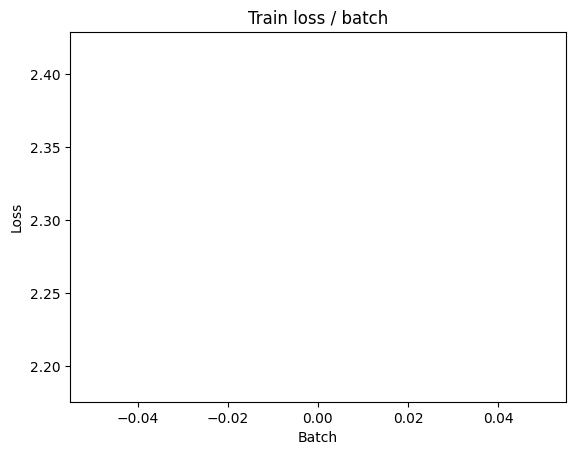

[TRAIN Batch 200/469]	Time 0.011s (0.030s)	Loss 0.3223 (1.1714)	Prec@1  91.4 ( 67.8)	Prec@5  99.2 ( 90.9)


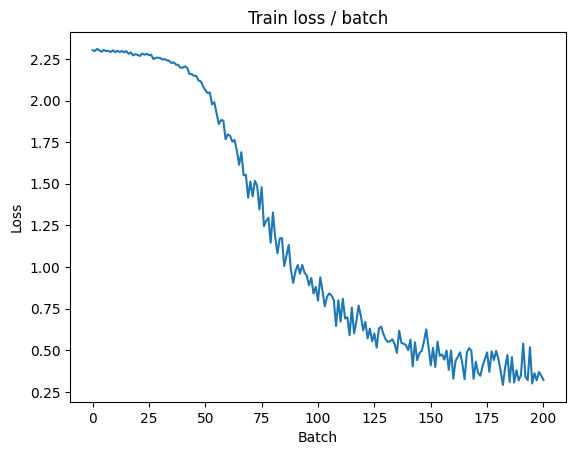

[TRAIN Batch 400/469]	Time 0.033s (0.023s)	Loss 0.3970 (0.7138)	Prec@1  90.6 ( 80.3)	Prec@5  98.4 ( 95.2)


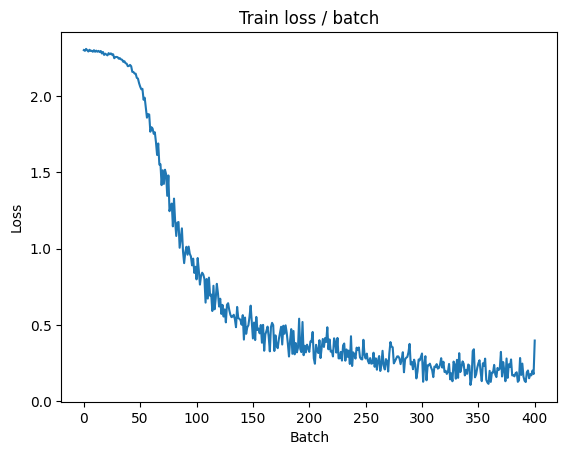


===============> Total time 10s	Avg loss 0.6356	Avg Prec@1 82.45 %	Avg Prec@5 95.89 %

[EVAL Batch 000/079]	Time 0.094s (0.094s)	Loss 0.1070 (0.1070)	Prec@1  97.7 ( 97.7)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.1457	Avg Prec@1 95.59 %	Avg Prec@5 99.94 %



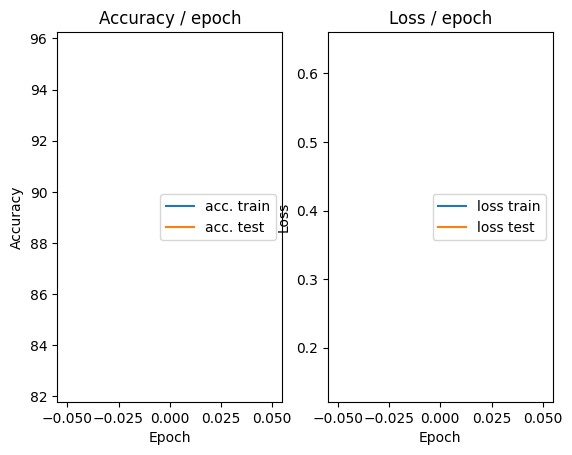

=== EPOCH 2 =====

[TRAIN Batch 000/469]	Time 0.112s (0.112s)	Loss 0.1523 (0.1523)	Prec@1  96.1 ( 96.1)	Prec@5  99.2 ( 99.2)


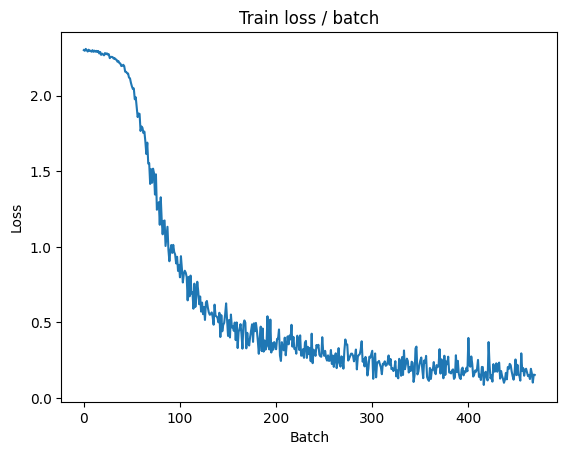

[TRAIN Batch 200/469]	Time 0.008s (0.018s)	Loss 0.1066 (0.1347)	Prec@1  96.9 ( 96.0)	Prec@5 100.0 ( 99.9)


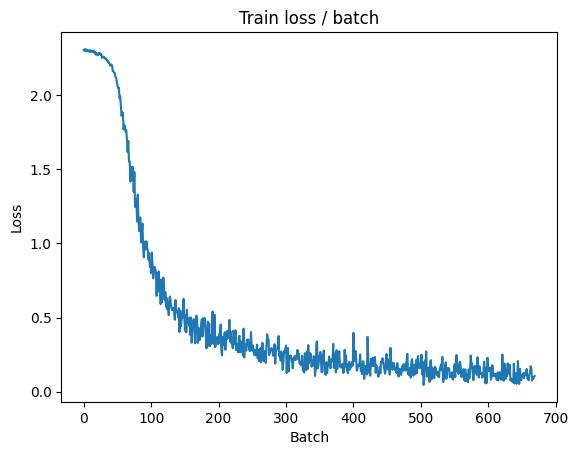

[TRAIN Batch 400/469]	Time 0.006s (0.019s)	Loss 0.0921 (0.1206)	Prec@1  96.9 ( 96.4)	Prec@5 100.0 ( 99.9)


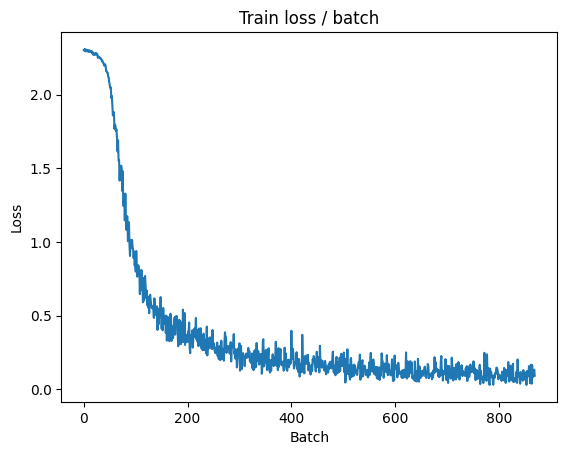


===============> Total time 8s	Avg loss 0.1170	Avg Prec@1 96.54 %	Avg Prec@5 99.89 %

[EVAL Batch 000/079]	Time 0.093s (0.093s)	Loss 0.0339 (0.0339)	Prec@1 100.0 (100.0)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.0780	Avg Prec@1 97.73 %	Avg Prec@5 100.00 %



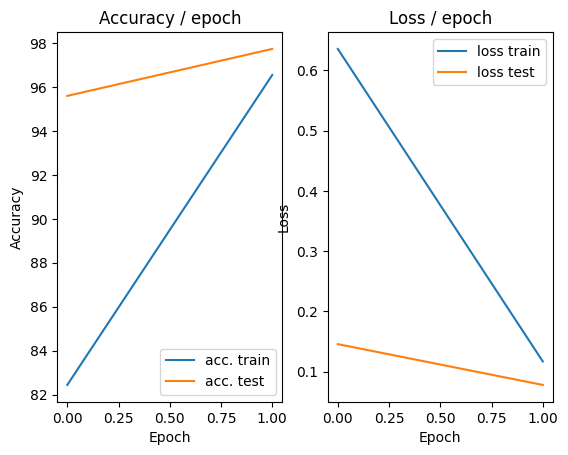

=== EPOCH 3 =====

[TRAIN Batch 000/469]	Time 0.110s (0.110s)	Loss 0.0811 (0.0811)	Prec@1  96.9 ( 96.9)	Prec@5 100.0 (100.0)


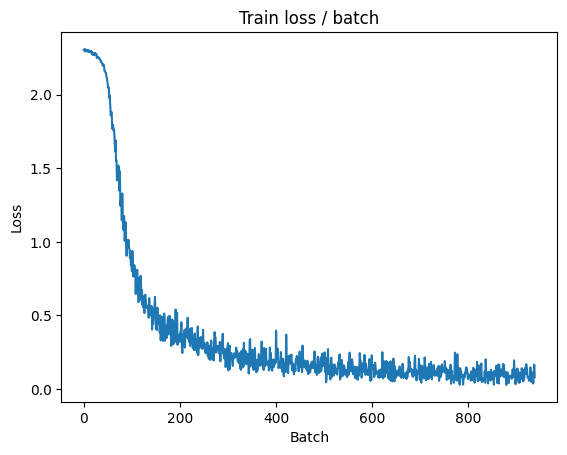

[TRAIN Batch 200/469]	Time 0.008s (0.017s)	Loss 0.0920 (0.0823)	Prec@1  96.9 ( 97.6)	Prec@5 100.0 (100.0)


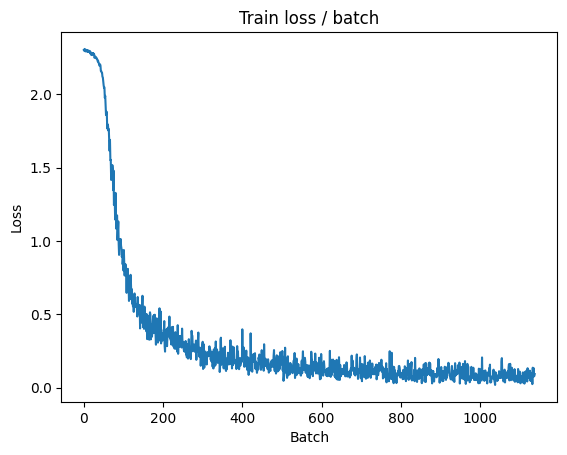

[TRAIN Batch 400/469]	Time 0.034s (0.019s)	Loss 0.1205 (0.0796)	Prec@1  96.9 ( 97.6)	Prec@5 100.0 (100.0)


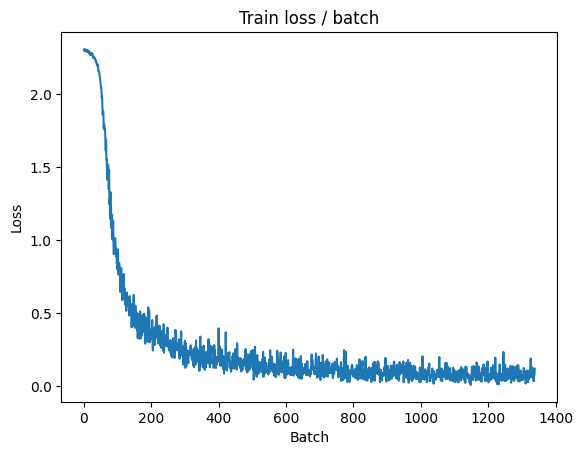


===============> Total time 9s	Avg loss 0.0784	Avg Prec@1 97.65 %	Avg Prec@5 99.94 %

[EVAL Batch 000/079]	Time 0.101s (0.101s)	Loss 0.0257 (0.0257)	Prec@1 100.0 (100.0)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.0588	Avg Prec@1 98.16 %	Avg Prec@5 100.00 %



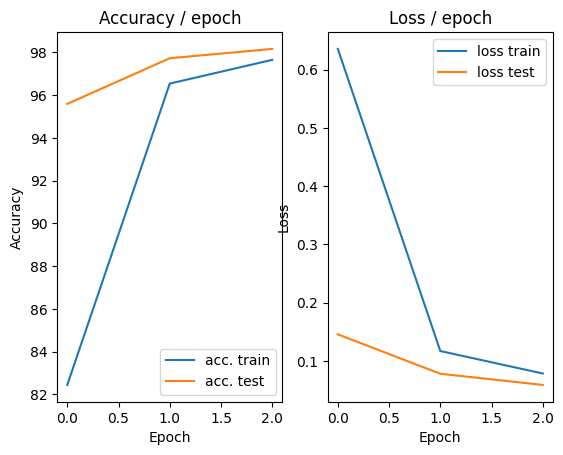

=== EPOCH 4 =====

[TRAIN Batch 000/469]	Time 0.119s (0.119s)	Loss 0.0240 (0.0240)	Prec@1  99.2 ( 99.2)	Prec@5 100.0 (100.0)


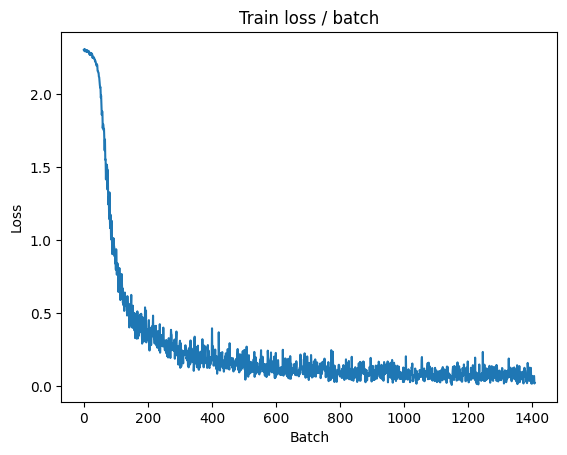

[TRAIN Batch 200/469]	Time 0.009s (0.017s)	Loss 0.0599 (0.0657)	Prec@1  97.7 ( 98.1)	Prec@5 100.0 (100.0)


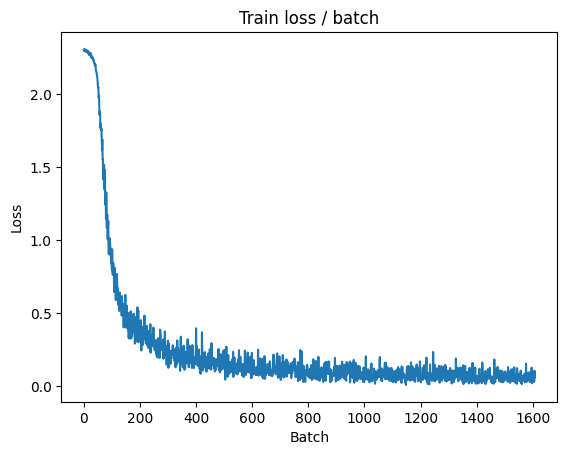

[TRAIN Batch 400/469]	Time 0.020s (0.016s)	Loss 0.0760 (0.0613)	Prec@1  96.9 ( 98.2)	Prec@5 100.0 (100.0)


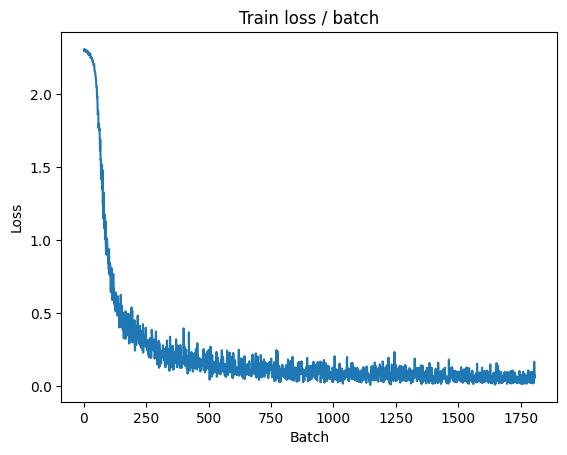


===============> Total time 8s	Avg loss 0.0605	Avg Prec@1 98.24 %	Avg Prec@5 99.96 %

[EVAL Batch 000/079]	Time 0.146s (0.146s)	Loss 0.0126 (0.0126)	Prec@1 100.0 (100.0)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.0524	Avg Prec@1 98.41 %	Avg Prec@5 100.00 %



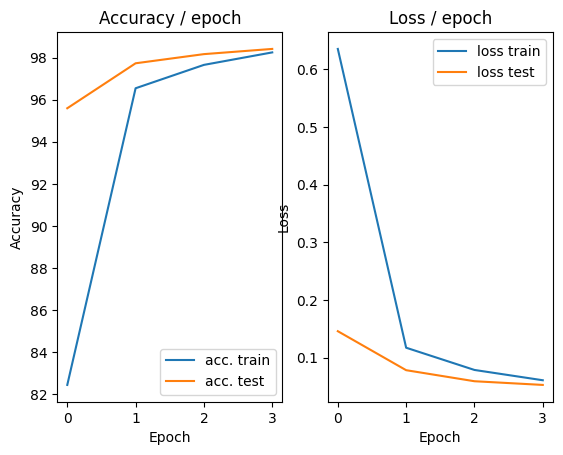

=== EPOCH 5 =====

[TRAIN Batch 000/469]	Time 0.127s (0.127s)	Loss 0.0427 (0.0427)	Prec@1  98.4 ( 98.4)	Prec@5 100.0 (100.0)


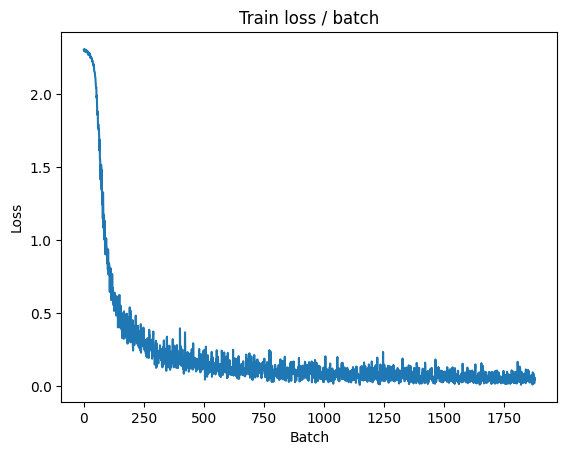

[TRAIN Batch 200/469]	Time 0.004s (0.018s)	Loss 0.0541 (0.0490)	Prec@1  97.7 ( 98.5)	Prec@5 100.0 (100.0)


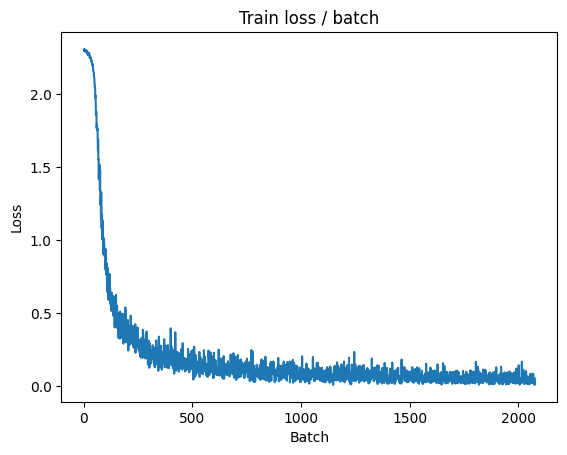

[TRAIN Batch 400/469]	Time 0.006s (0.017s)	Loss 0.0251 (0.0514)	Prec@1  99.2 ( 98.4)	Prec@5 100.0 (100.0)


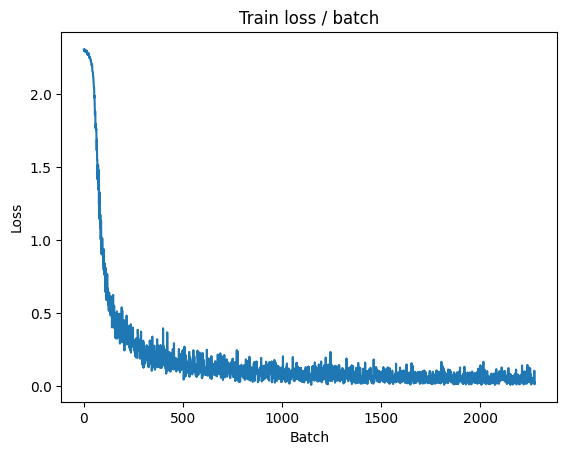


===============> Total time 8s	Avg loss 0.0508	Avg Prec@1 98.45 %	Avg Prec@5 99.98 %

[EVAL Batch 000/079]	Time 0.105s (0.105s)	Loss 0.0166 (0.0166)	Prec@1  99.2 ( 99.2)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.0414	Avg Prec@1 98.71 %	Avg Prec@5 100.00 %



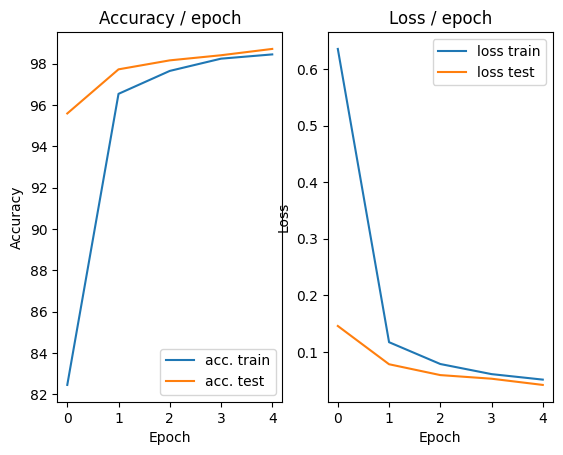

In [4]:
main(128, 0.1, cuda=True)

14. Différence train / test

En train, la loss est utilisée pour mettre à jour les poids (backpropagation), alors qu’en test il n’y a pas de mise à jour. Le modèle est en mode évaluation, donc on mesure seulement ses performances.

QST15


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

# Dataset CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

# Modèle CNN demandé
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 5, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 5, padding=2)
        self.conv3 = nn.Conv2d(64, 64, 5, padding=2)

        self.fc1 = nn.Linear(64 * 4 * 4, 1000)
        self.fc2 = nn.Linear(1000, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 32x32 → 16x16
        x = self.pool(F.relu(self.conv2(x)))  # 16x16 → 8x8
        x = self.pool(F.relu(self.conv3(x)))  # 8x8 → 4x4

        x = x.view(-1, 64 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialisation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Entraînement
for epoch in range(20):
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.3f}")

# Test
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

100%|██████████| 170M/170M [00:04<00:00, 40.6MB/s]


Epoch 1, Loss: 3138.926
Epoch 2, Loss: 2407.902
Epoch 3, Loss: 2104.706
Epoch 4, Loss: 1877.388
Epoch 5, Loss: 1683.406
Epoch 6, Loss: 1520.306
Epoch 7, Loss: 1386.442
Epoch 8, Loss: 1268.247
Epoch 9, Loss: 1164.868
Epoch 10, Loss: 1063.588
Epoch 11, Loss: 973.051
Epoch 12, Loss: 886.225
Epoch 13, Loss: 801.062
Epoch 14, Loss: 712.467
Epoch 15, Loss: 632.638
Epoch 16, Loss: 546.068
Epoch 17, Loss: 468.979
Epoch 18, Loss: 388.460
Epoch 19, Loss: 319.802
Epoch 20, Loss: 252.597
Accuracy: 74.85%


Après modification du code pour utiliser CIFAR-10 et l’architecture demandée, le modèle converge mais atteint une précision moyenne (environ–70%). Les performances sont plus faibles que sur MNIST car les images sont plus complexes.

16. Effet du learning rate et batch size

Un learning rate élevé peut rendre l’apprentissage instable, tandis qu’un faible le ralentit. Un batch size petit rend l’apprentissage plus bruité, alors qu’un grand le rend plus stable.

17. Erreur au début

L’erreur initiale est élevée car les poids sont aléatoires. Le modèle fait donc des prédictions proches du hasard.

18. Interprétation des résultats

On observe souvent un écart entre les performances train et test, ce qui indique du sur-apprentissage. Le modèle ne généralise pas bien aux nouvelles données.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

# ======================
# 1. Data (Normalization + Augmentation)
# ======================

transform_train = transforms.Compose([
    transforms.RandomCrop(28),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.491, 0.482, 0.447),
                         (0.202, 0.199, 0.201))
])

transform_test = transforms.Compose([
    transforms.CenterCrop(28),
    transforms.ToTensor(),
    transforms.Normalize((0.491, 0.482, 0.447),
                         (0.202, 0.199, 0.201))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

# ======================
# 2. Model (CNN amélioré)
# ======================

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 5, padding=2)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 5, padding=2)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 64, 5, padding=2)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2, ceil_mode=True)

        self.fc1 = nn.Linear(64 * 4 * 4, 1000)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(1000, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(-1, 64 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ======================
# 3. Training setup
# ======================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Scheduler (question 26)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

# ======================
# 4. Training
# ======================

for epoch in range(20):
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.3f}")

# ======================
# 5. Evaluation
# ======================

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

Epoch 1, Loss: 2300.480
Epoch 2, Loss: 1750.766
Epoch 3, Loss: 1539.464
Epoch 4, Loss: 1399.860
Epoch 5, Loss: 1301.083
Epoch 6, Loss: 1232.133
Epoch 7, Loss: 1168.449
Epoch 8, Loss: 1118.171
Epoch 9, Loss: 1073.693
Epoch 10, Loss: 1038.526
Epoch 11, Loss: 999.169
Epoch 12, Loss: 974.483
Epoch 13, Loss: 954.073
Epoch 14, Loss: 920.027
Epoch 15, Loss: 899.060
Epoch 16, Loss: 878.124
Epoch 17, Loss: 856.847
Epoch 18, Loss: 840.293
Epoch 19, Loss: 820.094
Epoch 20, Loss: 809.638
Accuracy: 81.68%


19. Résultats (normalisation)

La normalisation rend l’apprentissage plus stable et plus rapide. Elle améliore aussi légèrement la précision.

20. Pourquoi seulement sur train

On utilise uniquement le train pour éviter d’utiliser des informations du test. Cela garantit une évaluation correcte.

21. ZCA (bonus)

La normalisation ZCA enlève les corrélations entre pixels et peut améliorer les résultats. Elle est plus complexe à calculer.

22. Résultats (data augmentation)

La data augmentation améliore la généralisation et réduit le sur-apprentissage. Les performances en test augmentent.

23. Symétrie horizontale

Elle est adaptée aux objets symétriques (animaux, objets). Elle ne convient pas aux images avec orientation (texte).

24. Limites

Les transformations sont artificielles et limitées. Elles ne remplacent pas de vraies nouvelles données.

25. Autres méthodes (bonus)

On peut utiliser rotation, zoom, bruit ou changement de luminosité. Des méthodes comme Mixup ou CutMix existent aussi.

26. Résultats (scheduler)

Le scheduler améliore la stabilité et la convergence. Le modèle atteint souvent une meilleure précision.

27. Pourquoi ça marche

Réduire le learning rate permet d’ajuster finement les poids. Cela évite les oscillations en fin d’apprentissage.

28. Autres variantes (bonus)

On peut utiliser Adam, RMSprop ou SGD avec momentum. Il existe aussi cosine decay ou step decay.

29. Résultats (dropout)

Le dropout réduit le sur-apprentissage. Il améliore la performance sur les données de test.

30. Régularisation

La régularisation limite la complexité du modèle. Elle aide à mieux généraliser.

31. Effet du dropout

Le dropout empêche le réseau de dépendre de certains neurones. Il rend le modèle plus robuste.

32. Influence du paramètre

Un dropout trop fort empêche d’apprendre, trop faible est inutile. Il faut un bon équilibre.

33. Train vs test

En train, des neurones sont désactivés aléatoirement. En test, tous les neurones sont utilisés.

34. Résultats (batch normalization)

La batch normalization stabilise et accélère l’apprentissage. Elle améliore les performances globales.